# Parameter tuning for Terschelling

## Paths and settings

In [1]:
new_initial_state = False
new_tuning = False

In [2]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_tc = path_to_data_folder + '01_tides/output/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '12_13_Ters_DEM/input/'
path_output = path_to_data_folder + '12_13_Ters_DEM/output/'
path_altimetry_output = path_to_data_folder + '11_Ters_altimetry/output/'
path_transect_polys = path_to_data_folder + '05_Ters_transect_polys/'

# filename for gebco
fn_gebco = 'gebco_2023_n53.5439_s53.2693_w5.0194_e5.6607.nc'

epsg_local = 28992 # Amersfoort
epsg = 4326 # WGS84

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1

import warnings
warnings.filterwarnings("ignore")

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools

import P2_functions

In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Static parameters

In [5]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Sea level

In [6]:
# Altimetry
fn = 'tp_plus_ales_epsg28992.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [7]:
# Tidal correction
fn = 'tides_ters.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

### Shorelines

In [8]:
# Cassie shorelines
folders = ['12_cassie_landsat_1984-04-30_1992-09-04_ext1000_spac5000_base2_multi-thresh/',\
          '13_cassie_landsat_1992-09-20_2003-08-02_ext1000_spac5000_base2_multi-thresh/',\
          '18_cassie_landsat_2003-09-19_2015-03-12_ext1300_spac5000_base1_multi-thresh/',\
          '17_cassie_landsat_2015-04-13_2023-02-22_ext1300_spac5000_base1_multi-thresh/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'/1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

118 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 790 points (min: 156, max: 1475).


In [9]:
med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=100, transect_length=5000, smooth_factor=100)
t_factor = 1 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, med_sl, epsg, t_factor)
pickle.dump(c_shorelines_corr, open(path_output + 'c_shorelines_corr.pkl', 'wb'))

19.0% of shoreline points were discarded.


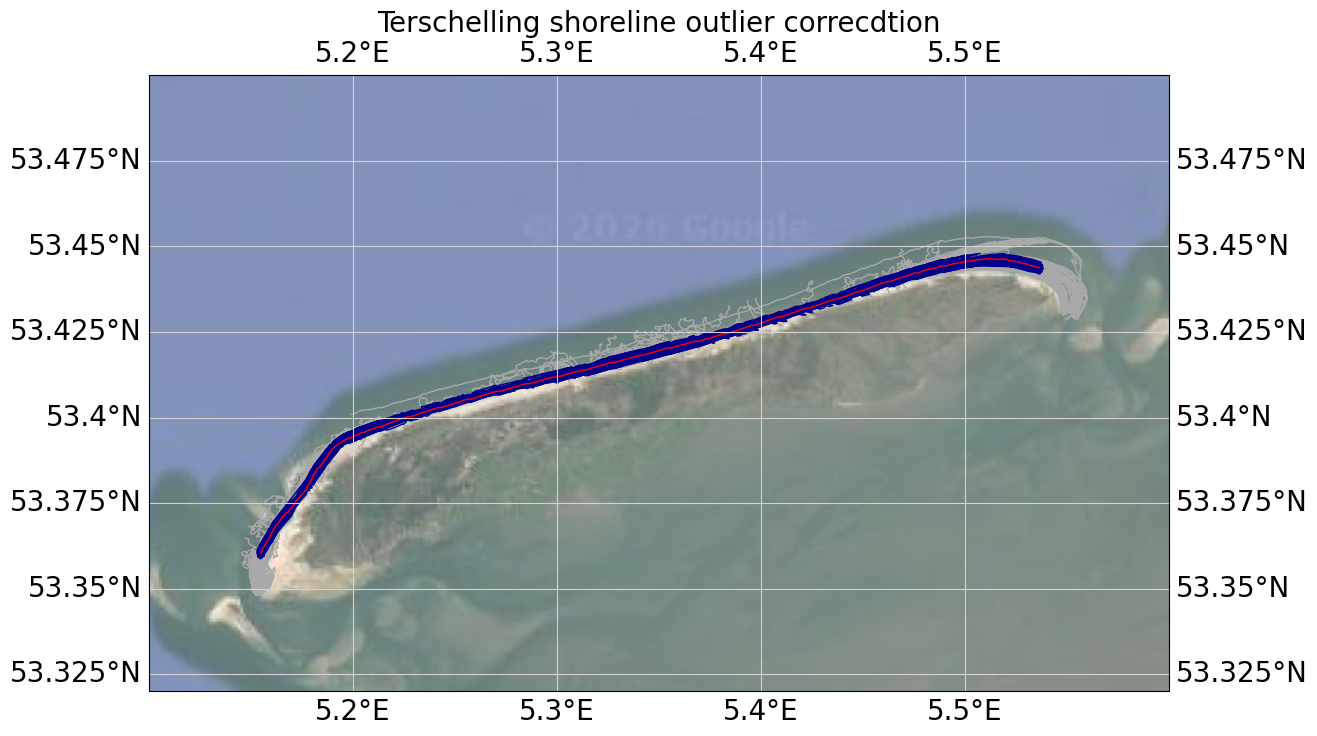

In [27]:
# Visual inspection of shoreline outlier rejectio
projection = ccrs.PlateCarree()

request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='red')

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkgrey', zorder=1, alpha=1)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

ax.set_title('Terschelling shoreline outlier correcdtion')

plt.savefig(f'{path_output}shoreline_outlier_rejection.png', dpi=300, bbox_inches='tight')

### Transect polygons

In [11]:
transect_polys = pickle.load(open(path_transect_polys + 'transect_polys.pkl', 'rb'))

## Initial state

In [12]:
resolution = CD_geometry.dist_meter_to_dist_deg(100) # [deg], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_100m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    # Target area: polgon around the shorelines
    poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=resolution)
    pickle.dump(poly_sl_corr, open(path_output + f'poly_sl_corr{epsg}.pkl', 'wb'))

    # Initial state
    smooth_factor = 100 # Smoothing of shorelines used to compute the median shoreline
    CD_kalman.initial_state(poly_sl_corr, med_sl, epsg, resolution, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco)
else:
    poly_sl_corr = pickle.load(open(path_output + f'poly_sl_corr{epsg}.pkl', 'rb'))

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [14]:
init = xr.open_dataset(path_output+fn_init).squeeze()

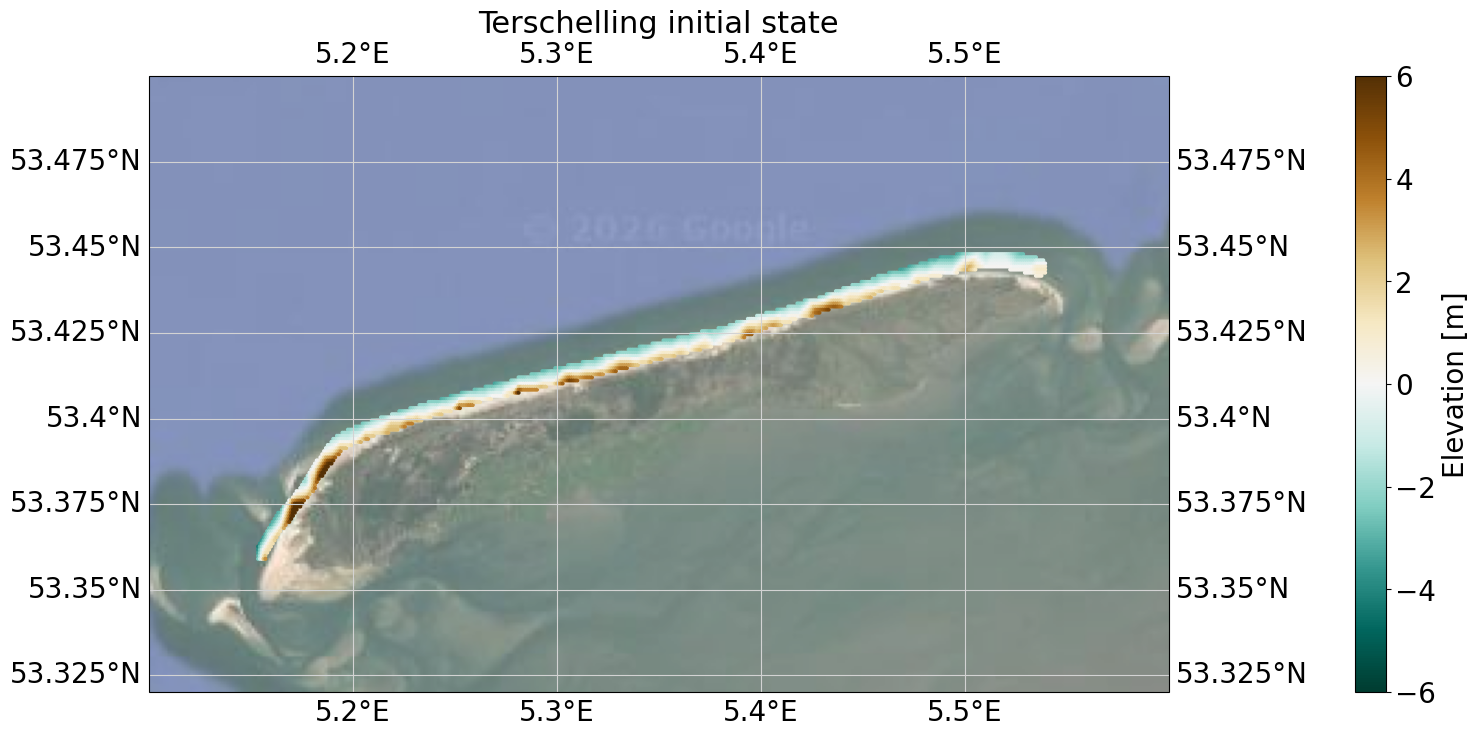

In [31]:
# Plot intial state
init_df = init.to_dataframe().dropna()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)
plot = ax.scatter(x, y, c=init_df['band_data'], transform=projection, marker='.', s=15,
                  cmap='BrBG_r', vmin=-6, vmax=6)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Terschelling initial state', fontsize=22);

plt.savefig(f'{path_output}Ters_initial_state.png', dpi=300, bbox_inches='tight')

## Jarkus data

In [16]:
jarkus_gdf = CD_jarkus_tools.get_jarkus_data(path_input_general, year_start, year_end, poly_sl_corr, init)

In [17]:
# thin out the grid so that there are approximately 700 values left, as evenly spaced as possible
temp = init.band_data.values.reshape(-1)
num_values = len(temp[~np.isnan(temp)])

thin_out_factor = int(len(jarkus_gdf) / num_values)
jarkus_gdf = jarkus_gdf.iloc[::thin_out_factor]

jarkus_gdf = jarkus_gdf.set_crs('4326')
jarkus_gdf = jarkus_gdf.reset_index(drop=True)

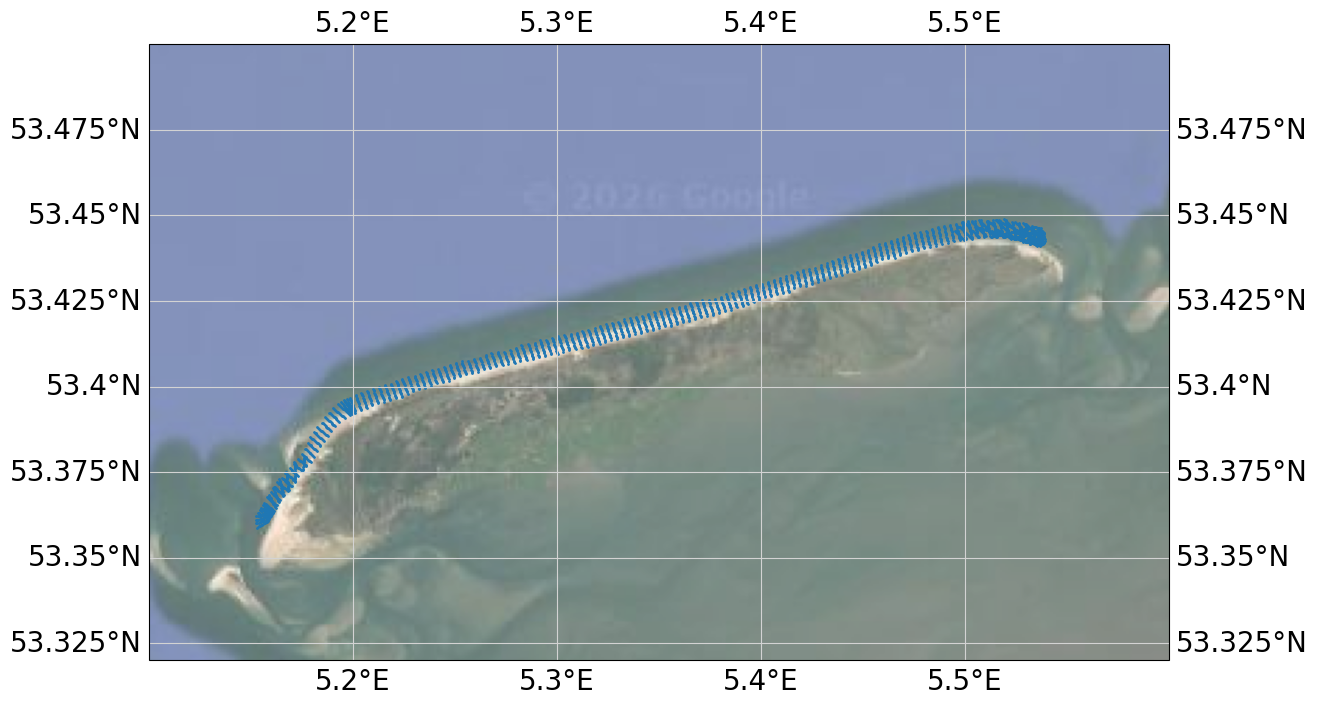

In [18]:
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

ax.scatter(jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, s=1, transform=ccrs.PlateCarree())

### Remove height difference between validation and new DTM
with bias from notebook 13

In [19]:
bias = pickle.load(open(path_output + 'bias.pkl', 'rb'))
jarkus_red = jarkus_gdf.copy()
jarkus_red.loc[:, jarkus_red.columns != 'geometry'] += bias

## Tune

In [20]:
# sigma_l
# Minimum combined error
beach_slope_min = 0.001
rmse_h_cassie_min = 5
std_alt_min = 0.03
rms_eot20_min = 0.01 # from paper, table 3: 0.061
sigma_v_total_min = np.sqrt((beach_slope_min * rmse_h_cassie_min)**2 + std_alt_min**2 + rms_eot20_min**2)

# Maximum combined error
beach_slope_max = 0.02
rmse_h_cassie_max = 50
std_alt_max = .8
rms_eot20_max = 0.1
sigma_v_total_max = np.sqrt((beach_slope_max * rmse_h_cassie_max)**2 + std_alt_max**2 + rms_eot20_max**2)

print(f'Min: {round(sigma_v_total_min,2)} m, Max: {round(sigma_v_total_max,2)} m')

Min: 0.03 m, Max: 1.28 m


In [21]:
sigma_l_values =  np.linspace(sigma_v_total_min, sigma_v_total_max, 5) # [m]
factors = [1, 10, 25]
std_init_values = [1, 3, 9] # [m]

param_df = pd.DataFrame(list(itertools.product(factors, sigma_l_values, std_init_values)), columns=['factor', 'sigma_l', 'std_init'])

param_df['sigma_q'] = param_df['factor'] * param_df['sigma_l']
param_df

,factor,sigma_l,std_init,sigma_q
0,1,0.032016,1,0.032016
1,1,0.032016,3,0.032016
2,1,0.032016,9,0.032016
3,1,0.345143,1,0.345143
4,1,0.345143,3,0.345143
5,1,0.345143,9,0.345143
6,1,0.658269,1,0.658269
7,1,0.658269,3,0.658269
8,1,0.658269,9,0.658269
9,1,0.971396,1,0.971396


In [22]:
if new_tuning:
    year_ref = 2006
    n_iter = 2
    
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m]
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Initialise DataFrames to store volume statistics
    rmse_df = pd.DataFrame()
    corr_df = pd.DataFrame()
    pvalues_df = pd.DataFrame()
    trend_df = pd.DataFrame()
    errors_df = pd.DataFrame()
    
    for i in param_df.index:
        factor = param_df.loc[i, 'factor']
        sigma_q = param_df.loc[i, 'sigma_q']
        sigma_l = param_df.loc[i, 'sigma_l']
        std_init = param_df.loc[i, 'std_init']
        print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')        
        
        # Initialise state vector
        init_df = init.to_dataframe().dropna()
        x = init_df.index.get_level_values('x')
        y = init_df.index.get_level_values('y')    
        x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
        x_state = x_state.set_crs(epsg)

        # Covariance matrix of the initial state
        sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
        sigma_xx_init = diags_array(sigma_xx_init_df.sigma)

        # "Iteration 0"
        x_k = x_state['init'].copy()
        sigma_xx_k = sigma_xx_init

        # Initial trend 
        trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)

        for j in range(0, n_iter):
            x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
                  x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
                  seg_length, alt, tidal_corr, epsg, epsg_local, T_is_identity, max_distance, w_id,
                  max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref)

            # New trend
            trends[f'trend_{j}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
            # Overwrite  trend_k for next iteration
            trends['trend_k'] = trends[f'trend_{j}'].copy()

            # Overwrite x_k so that next iteration starts with residuals and not the full signal
            x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
            sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

        x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

        # Re-add trend
        x_state_readd = x_state.copy()
        x_state_s_readd = x_state_s.copy()

        all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
        trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

        year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
        for year in year_list:
            deltaYear = year - year_ref
            x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
            x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
            x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

        kf_interp, rts_interp = CD_kalman.interpolate_results(jarkus_gdf, x_state_readd, x_state_s_readd)
        
        # Remove years with missing data
        jarkus_red = jarkus_red.drop(columns=['2001','2002', '2003', '2012'], errors='ignore')
        kf_interp = kf_interp.drop(columns=['2001', '2003'], errors='ignore')
        rts_interp = rts_interp.drop(columns=['2001', '2003'], errors='ignore')
 
        # Compute volumes
        volumes_jarkus, volumes_kf, volumes_rts = P2_functions.get_all_volumes(
            jarkus_red, kf_interp, rts_interp, transect_polys, epsg_local)
        
        volumes_jarkus_west, volumes_jarkus_middle, volumes_jarkus_east, \
        volumes_kf_west, volumes_kf_middle, volumes_kf_east, \
        volumes_rts_west, volumes_rts_middle, volumes_rts_east = P2_functions.split_Ters(
                                                                volumes_jarkus, volumes_kf, volumes_rts)
        # Volume change statistics compared with validation
        trends, trend_diff_perc, corr, pvalues, rmse, rmse_perc = P2_functions.volume_stats_Ters(
                volumes_jarkus, volumes_kf, volumes_rts,
                volumes_jarkus_west, volumes_jarkus_middle, volumes_jarkus_east,
                volumes_kf_west, volumes_kf_middle, volumes_kf_east, 
                volumes_rts_west, volumes_rts_middle, volumes_rts_east, print_output=False)

        # ToDo: save trend_diff_perc and rmse_perc
        rmse_df[i] = pd.DataFrame([rmse]).T[0]
        corr_df[i] = pd.DataFrame([corr]).T[0]
        pvalues_df[i] = pd.DataFrame([pvalues]).T[0]
        trend_df[i] = pd.DataFrame([trends]).T[0]
    
    rmse_df.to_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df.to_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df.to_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df.to_pickle(path_output+'partun_volumes_trends.pkl')
        
else:
    rmse_df = pd.read_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df = pd.read_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df = pd.read_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df = pd.read_pickle(path_output+'partun_volumes_trends.pkl')
    print("Loaded files.")

Loaded files.


#### Percentages

In [23]:
# re-compute volumes of Jarkus for rmse percentages
# (would be better to save trend_diff_perc and rmse_perc in tuning loop)
volumes_jarkus = pd.DataFrame(index=[int(_) for _ in jarkus_gdf.drop(columns='geometry').columns])
for idx_transect in transect_polys.keys():
    volumes_jarkus[idx_transect] = CD_geometry.compute_volume_changes(jarkus_gdf, transect_polys[idx_transect], epsg_out=epsg_local)

# West Terschelling erosive section
idx_west = [25, 57]
# Middle accretive section
idx_middle = [58, 111]
# East Terschelling erosive section
idx_east = [112, 144]

In [24]:
total_vol_jarkus = {}
total_vol_jarkus['all'] = volumes_jarkus.mean(axis=1).mean()
total_vol_jarkus['west'] = volumes_jarkus.iloc[:, idx_west[0]:idx_west[1]].mean(axis=1).mean()
total_vol_jarkus['center'] = volumes_jarkus.iloc[:, idx_middle[0]:idx_middle[1]].mean(axis=1).mean()
total_vol_jarkus['east'] = volumes_jarkus.iloc[:, idx_east[0]:idx_east[1]].mean(axis=1).mean()

In [25]:
trend_diff_perc = pd.DataFrame(columns=['all', 'west', 'center', 'east'], index=param_df.index)
rmse_perc = pd.DataFrame(columns=['all', 'west', 'center', 'east'], index=param_df.index)

for area in trend_diff_perc.columns:
    trend_diff = trend_df.T[f'rts_{area}'] - trend_df.T[f'jarkus_{area}']

    # Find the parameter combinations where both trends have the same sign
    idx_pos, = np.where(np.sign(trend_df.T[f'rts_{area}']) == np.sign(trend_df.T[f'jarkus_{area}']))
    idx_neg, = np.where(np.sign(trend_df.T[f'rts_{area}']) != np.sign(trend_df.T[f'jarkus_{area}']))

    # Same sign: Quotient of absolute trends
    trend_diff_perc.loc[idx_pos, area] = (np.abs(trend_diff.loc[idx_pos]) / np.abs(trend_df.T[f'jarkus_{area}'])) * 100
    # Different sign: Trend diff perc should end up with negative sign
    trend_diff_perc.loc[idx_neg, area] = (trend_diff.loc[idx_neg] / trend_df.T[f'jarkus_{area}']) * 100

    rmse_perc[area] = (np.abs(rmse_df.T[area]) / np.abs(total_vol_jarkus[area])) * 100

## Plots

In [26]:
cmap = cm['Blues_r']
c_list = cmap(np.linspace(0,.6,3))
# c_list = ['purple', 'darkblue', 'limegreen'] # encode sigma_q (factors of sigma_l) with colour
ls_list = ['-', '-.', ':'] # encode sigma_gebco with linestyle

In [27]:
idx_selected = 19
param_df.iloc[idx_selected]

factor      10.000000
sigma_l      0.345143
std_init     3.000000
sigma_q      3.451425
Name: 19, dtype: float64

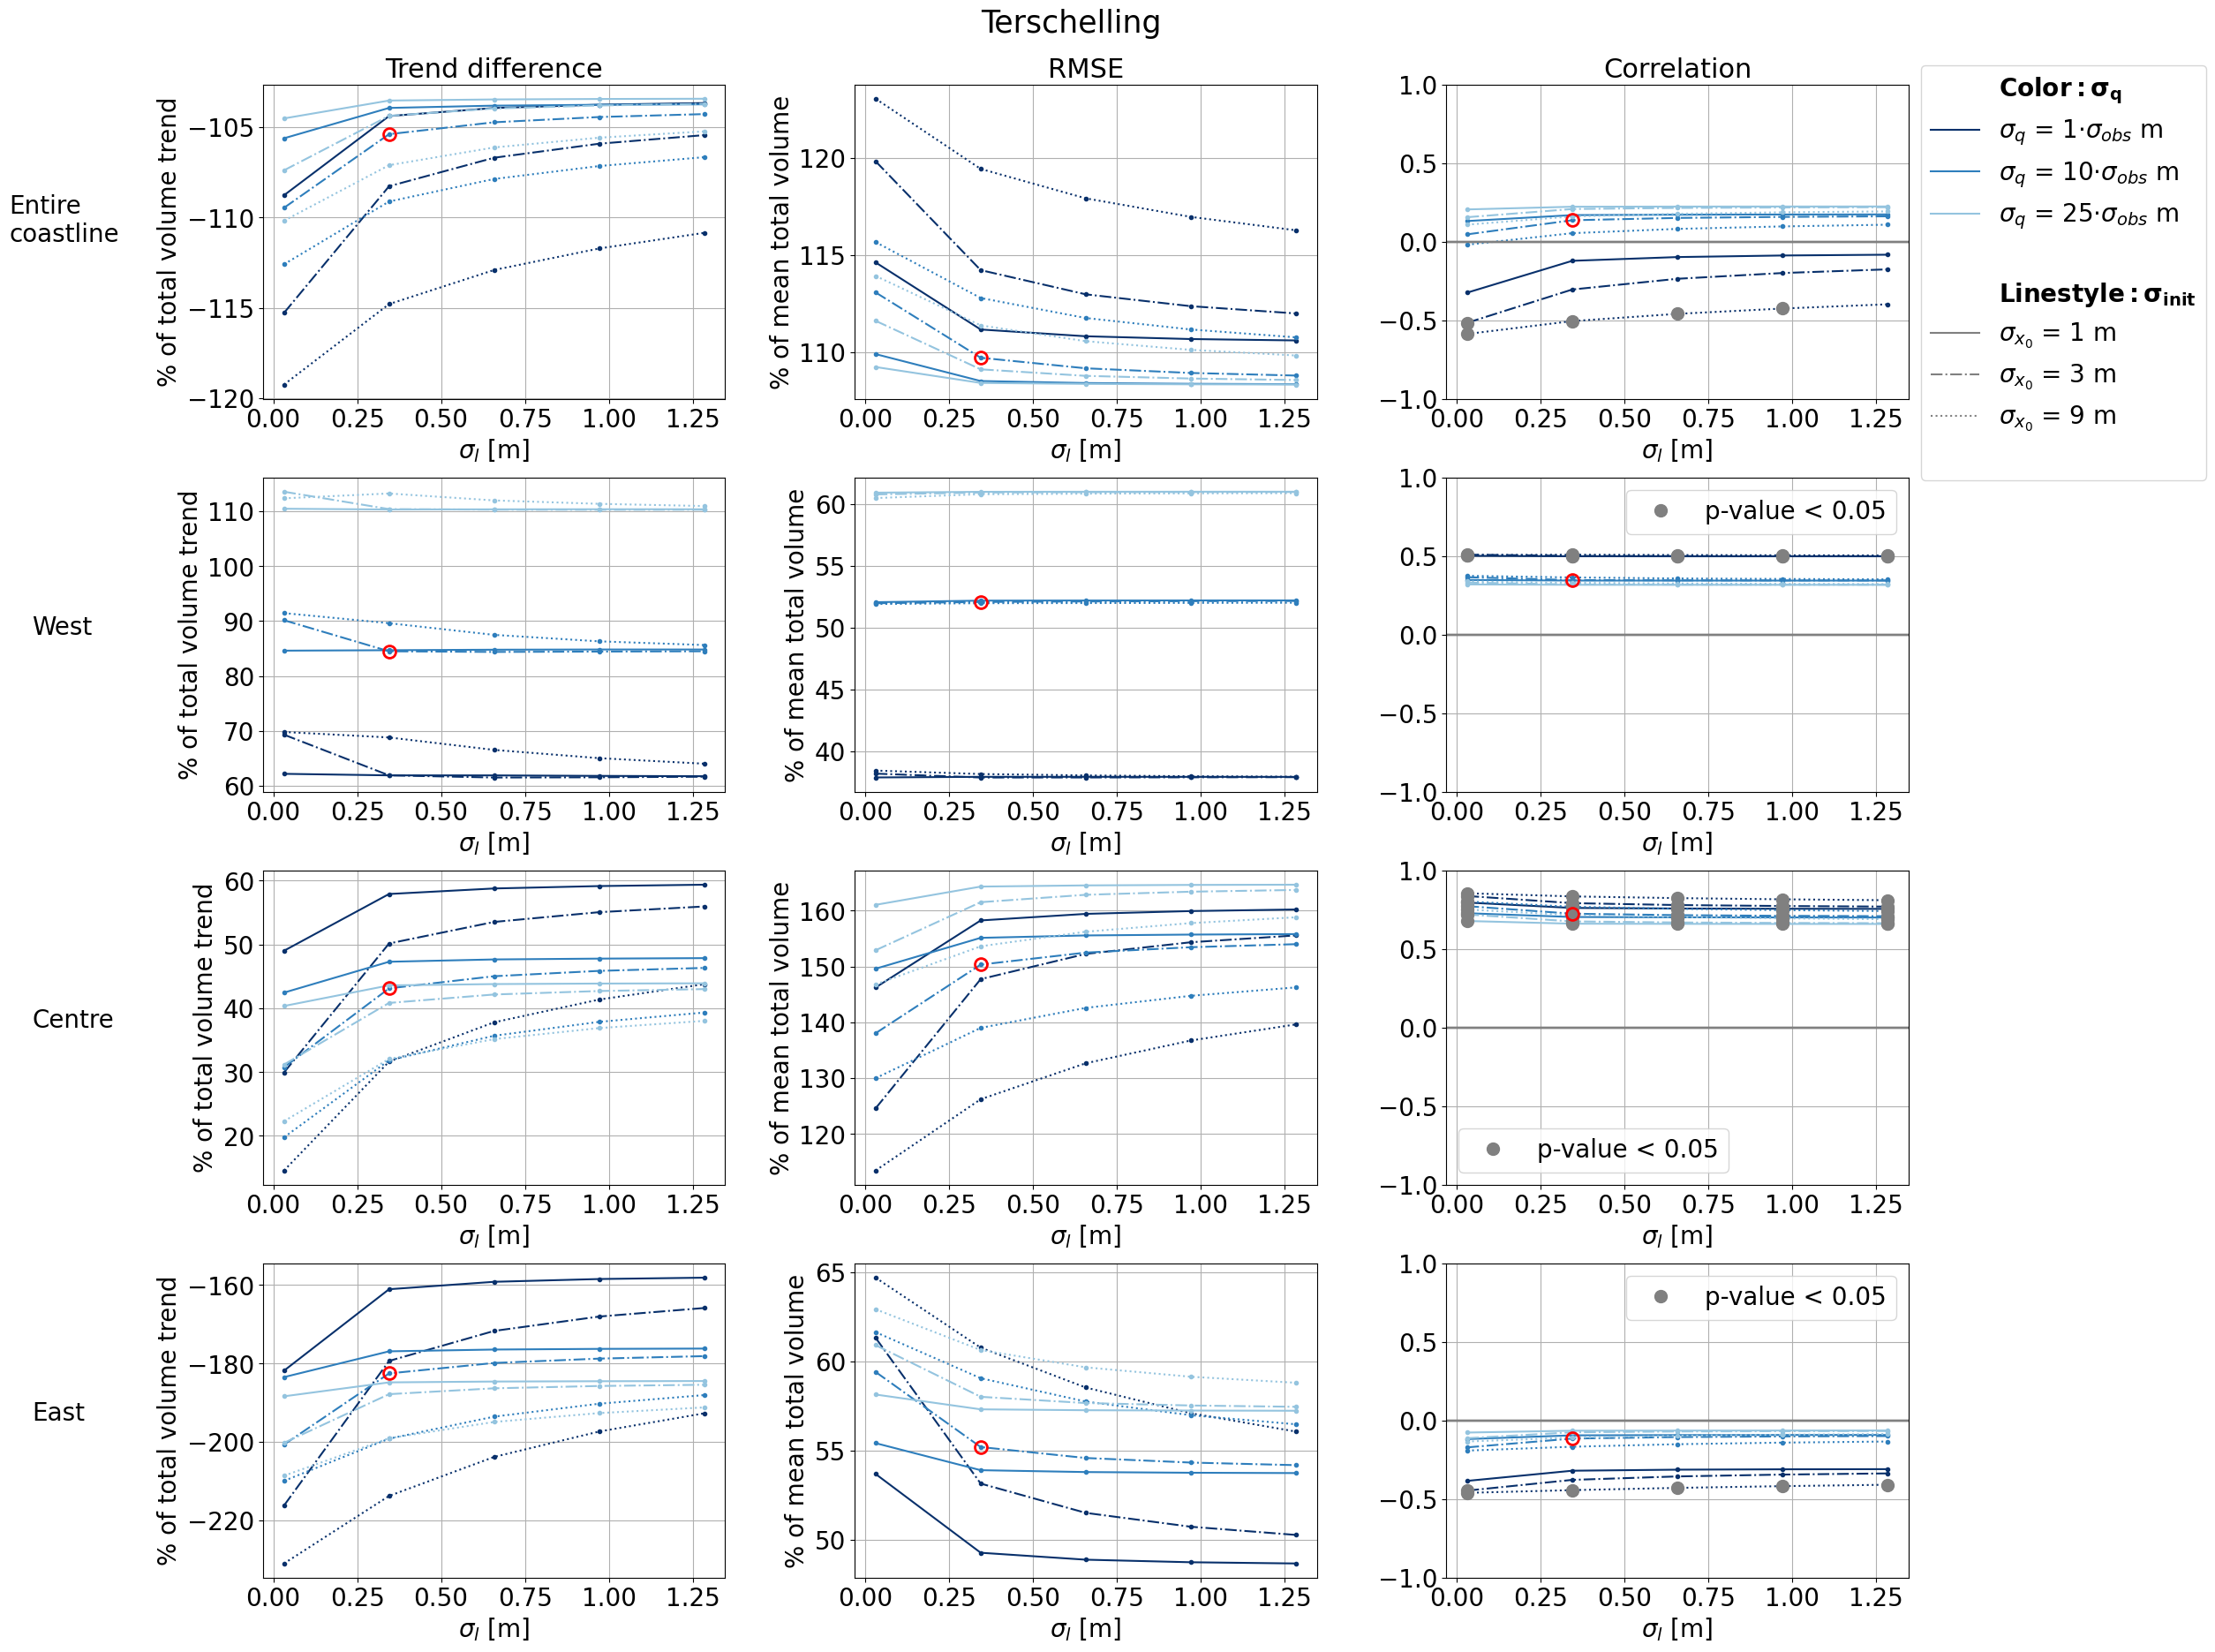

In [28]:
fig, axs = plt.subplots(4,3, figsize=(20,18))
fig.tight_layout()
fig.subplots_adjust(hspace=.25, wspace=.28)

for idx, area in enumerate(trend_diff_perc.columns):
    title = 'Trend difference' if idx==0 else ''
    P2_functions.plot_vol_stats(axs[idx,0], trend_diff_perc[area], pvalues_df.T[area], factors, std_init_values,
                            param_df, ls_list, c_list, ylabel='% of total volume trend', 
                            title=title, corr=False,
                            plot_zero=False, ylim=None)

    title = 'RMSE' if idx==0 else ''
    P2_functions.plot_vol_stats(axs[idx, 1], rmse_perc[area], pvalues_df.T[area], factors, std_init_values,
                            param_df, ls_list, c_list, ylabel='% of mean total volume', 
                            title=title, corr=False,
                            plot_zero=False, ylim=None)

    ylim_corr = [-1,1]
    title = 'Correlation' if idx==0 else ''
    P2_functions.plot_vol_stats(axs[idx, 2], corr_df.T[area], pvalues_df.T[area], factors, std_init_values,
                            param_df, ls_list, c_list, ylabel='', 
                            title=title, corr=True,
                            plot_zero=True, ylim=ylim_corr)

    P2_functions.mark_selected_param(axs[idx, 0], idx_selected, trend_diff_perc[area], param_df)
    P2_functions.mark_selected_param(axs[idx, 1], idx_selected, rmse_perc[area], param_df)
    P2_functions.mark_selected_param(axs[idx, 2], idx_selected, corr_df.T[area], param_df)

P2_functions.plot_legend(axs[0,2], c_list, ls_list, factors, std_init_values)
fig.suptitle('Terschelling', y=1.025, fontsize=25)

axs[0,0].text(-.55,.5, f'Entire\ncoastline', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(-.5,.5, f'West', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(-.5,.5, f'Centre', transform=axs[2,0].transAxes, fontsize=20)
axs[3,0].text(-.5,.5, f'East', transform=axs[3,0].transAxes, fontsize=20);

plt.savefig(f'{path_output}Ters_partun.png', dpi=300, bbox_inches='tight')